# ST456 Deep Learning - PCam Histopathology Classification


## Section 0 - Setup chunks 

In [1]:
# Mount Drive and clone repo
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!git clone https://github.com/Friedrich-233/ST456_GroupProject.git /content/ST456_GroupProject
!pip install timm -q
import sys
sys.path.insert(0, '/content/ST456_GroupProject/code')

Mounted at /content/drive
Cloning into '/content/ST456_GroupProject'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 149 (delta 8), reused 10 (delta 3), pack-reused 134 (from 1)
Receiving objects: 100% (149/149), 162.58 MiB | 17.39 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [ ]:
from pathlib import Path

# Paths - edit this to your Drive folder location  
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/ST456 Group project/pcamv1') 
DATA_DIR = Path('/content/pcam_data')
CHECKPOINT_DIR = Path('/content/ST456_GroupProject/checkpoints')
RESULTS_DIR = Path('/content/ST456_GroupProject/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Results:     {RESULTS_DIR}")

Checkpoints: /content/ST456_GroupProject/checkpoints
Results:     /content/ST456_GroupProject/results


In [3]:
from data import load_all_data, build_downstream_loaders, LABEL_FRACTIONS

print("Loading PCam data...")
data = load_all_data(
    drive_data_dir=DRIVE_DATA_DIR,
    data_dir=DATA_DIR,
    pretrain_fraction=0.15,
    downstream_pool_fraction=0.15,
    use_subset=True,
)

train_loaders, val_loader, test_loader = build_downstream_loaders(data)
print("\nLabel fractions:", list(LABEL_FRACTIONS.keys()))
print("Train loaders:", {k: len(v.dataset) for k, v in train_loaders.items()})

Loading PCam data...
Unzipping camelyonpatch_level_2_split_train_x.h5.gz -> /content/pcam_data/camelyonpatch_level_2_split_train_x.h5
Unzipping camelyonpatch_level_2_split_train_y.h5.gz -> /content/pcam_data/camelyonpatch_level_2_split_train_y.h5
Unzipping camelyonpatch_level_2_split_valid_x.h5.gz -> /content/pcam_data/camelyonpatch_level_2_split_valid_x.h5
Unzipping camelyonpatch_level_2_split_valid_y.h5.gz -> /content/pcam_data/camelyonpatch_level_2_split_valid_y.h5
Unzipping camelyonpatch_level_2_split_test_x.h5.gz -> /content/pcam_data/camelyonpatch_level_2_split_test_x.h5
Unzipping camelyonpatch_level_2_split_test_y.h5.gz -> /content/pcam_data/camelyonpatch_level_2_split_test_y.h5

Label fractions: ['1%', '5%', '10%']
Train loaders: {'1%': 393, '5%': 1966, '10%': 3932}


## Section 1 - Pre-training SSL Encoders

In [ ]:
from training import train_simclr, SEED

# Improve SimCLR tailored - 50 epochs, AdamW + cosine schedule + warmup
simclr_model, simclr_history, simclr_ckpt = train_simclr(
    data=data,
    checkpoint_dir=CHECKPOINT_DIR,
    epochs=50,
    batch_size=128,
    learning_rate=3e-4,
    warmup_epochs=2,
    weight_decay=0.05,
    tailored=True,
    checkpoint_name='simclr_encoder_tailored.pth',
)
print(f"\nSimCLR (tailored) checkpoint saved -> {simclr_ckpt}")

In [ ]:
# Plot SimCLR training loss
import pandas as pd, matplotlib.pyplot as plt

df = pd.DataFrame(simclr_history)
plt.figure(figsize=(8, 4))
plt.plot(df['epoch'], df['loss'], 'b-o')
plt.xlabel('Epoch'); plt.ylabel('NT-Xent Loss')
plt.title('SimCLR Training Curve')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

In [ ]:
# SimCLR GENERIC augmentation (ablation vs tailored)
simclr_model_generic, simclr_history_generic, simclr_ckpt_generic = train_simclr(
    data=data,
    checkpoint_dir=CHECKPOINT_DIR,
    epochs=50,
    batch_size=128,
    learning_rate=3e-4,
    warmup_epochs=2,
    weight_decay=0.05,
    tailored=False,                     # tailored to ablation
    checkpoint_name='simclr_encoder_generic.pth',
)
print(f"\nSimCLR (generic) checkpoint saved -> {simclr_ckpt_generic}")

In [ ]:
from training import train_mae

# MAE Improve — 50 epochs, lr=1.5e-4 (MAE paper's linear scaling), cosine + warmup
mae_model, mae_history, mae_ckpt = train_mae(
    data=data,
    checkpoint_dir=CHECKPOINT_DIR,
    epochs=50,
    batch_size=128,
    learning_rate=1.5e-4,
    warmup_epochs=2,
    weight_decay=0.05,
    checkpoint_name='mae_encoder.pth',
)
print(f"\nMAE checkpoint saved -> {mae_ckpt}")

In [ ]:
# Plot MAE training loss
df = pd.DataFrame(mae_history)
plt.figure(figsize=(8, 4))
plt.plot(df['epoch'], df['loss'], 'r-o')
plt.xlabel('Epoch'); plt.ylabel('Reconstruction Loss')
plt.title('MAE (Base) Training Curve')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

In [ ]:
import os


print("Pre-training Complete — Checkpoints")

for name, path in [
    ('SimCLR (tailored)',   CHECKPOINT_DIR / 'simclr_encoder_tailored.pth'),
    ('SimCLR (generic)',    CHECKPOINT_DIR / 'simclr_encoder_generic.pth'),   
    ('MAE (base)',          CHECKPOINT_DIR / 'mae_encoder.pth'),
]:
    status = 'FOUND' if path.exists() else 'MISSING'
    if path.exists():
        size_mb = os.path.getsize(path) / 1e6
        print(f"  {status}  {name:<22}  {size_mb:.1f} MB  {path}")
    else:
        print(f"  {status}  {name:<22}  (not found)")

## Section 2 - Downstream Experiment Grid


In [ ]:
# Run Section 0 first so that CHECKPOINT_DIR, RESULTS_DIR,
# data, train_loaders, val_loader, test_loader are all in scope.
import os
from training import (
    run_single_experiment,
    run_experiment_grid,
    TrainConfig,
    DEFAULT_EXPERIMENT_CONFIG,
    MAIN_METHODS,
    FINETUNE_STRATEGIES,
)

# Verify checkpoints produced by Section 1 are present
_ckpts = {
    'simclr_encoder_tailored.pth': CHECKPOINT_DIR / 'simclr_encoder_tailored.pth',
    'simclr_encoder_generic.pth':  CHECKPOINT_DIR / 'simclr_encoder_generic.pth',
    'mae_encoder.pth':             CHECKPOINT_DIR / 'mae_encoder.pth',
}
for _name, _path in _ckpts.items():
    if not _path.exists():
        raise FileNotFoundError(
            f"Checkpoint missing: {_path}\n"
            "Run Section 1 first, or copy the checkpoints into CHECKPOINT_DIR."
        )
    print(f"  checked -  {_name}")
print("All checkpoints found — ready to run experiments.")

  ✓  simclr_encoder_tailored.pth
  ✓  simclr_encoder_generic.pth
  ✓  mae_encoder.pth
All checkpoints found — ready to run experiments.


In [ ]:
# Grid A — Seed 42
results_42 = run_experiment_grid(
    methods=MAIN_METHODS,
    strategies=FINETUNE_STRATEGIES,
    label_names=list(LABEL_FRACTIONS.keys()),
    seeds=[42],
    train_loaders=train_loaders,
    val_loader=val_loader,
    test_loader=test_loader,
    simclr_checkpoint=CHECKPOINT_DIR / 'simclr_encoder_tailored.pth',
    mae_checkpoint=CHECKPOINT_DIR / 'mae_encoder.pth',
    config=DEFAULT_EXPERIMENT_CONFIG,
)
results_42.to_csv(RESULTS_DIR / 'results_seed42.csv', index=False)
print(f"Seed 42 done — {len(results_42)} rows -> {RESULTS_DIR / 'results_seed42.csv'}")
display(results_42)

In [ ]:
# Grid B — Seed 52
results_52 = run_experiment_grid(
    methods=MAIN_METHODS,
    strategies=FINETUNE_STRATEGIES,
    label_names=list(LABEL_FRACTIONS.keys()),
    seeds=[52],
    train_loaders=train_loaders,
    val_loader=val_loader,
    test_loader=test_loader,
    simclr_checkpoint=CHECKPOINT_DIR / 'simclr_encoder_tailored.pth',
    mae_checkpoint=CHECKPOINT_DIR / 'mae_encoder.pth',
    config=DEFAULT_EXPERIMENT_CONFIG,
)
results_52.to_csv(RESULTS_DIR / 'results_seed52.csv', index=False)
print(f"Seed 52 done — {len(results_52)} rows -> {RESULTS_DIR / 'results_seed52.csv'}")
display(results_52)

In [ ]:
# Grid C — Seed 62
results_62 = run_experiment_grid(
    methods=MAIN_METHODS,
    strategies=FINETUNE_STRATEGIES,
    label_names=list(LABEL_FRACTIONS.keys()),
    seeds=[62],
    train_loaders=train_loaders,
    val_loader=val_loader,
    test_loader=test_loader,
    simclr_checkpoint=CHECKPOINT_DIR / 'simclr_encoder_tailored.pth',
    mae_checkpoint=CHECKPOINT_DIR / 'mae_encoder.pth',
    config=DEFAULT_EXPERIMENT_CONFIG,
)
results_62.to_csv(RESULTS_DIR / 'results_seed62.csv', index=False)
print(f"Seed 62 done — {len(results_62)} rows -> {RESULTS_DIR / 'results_seed62.csv'}")
display(results_62)

Running supervised_from_scratch | frozen | 1% | seed=62
epoch 1/15 | train_loss=0.7717 | val_auc=0.6858 | val_f1=0.0361
epoch 2/15 | train_loss=0.6754 | val_auc=0.6609 | val_f1=0.6746
epoch 3/15 | train_loss=0.6461 | val_auc=0.8260 | val_f1=0.3919
epoch 4/15 | train_loss=0.6648 | val_auc=0.8079 | val_f1=0.7425
epoch 5/15 | train_loss=0.6745 | val_auc=0.7665 | val_f1=0.7037
epoch 6/15 | train_loss=0.6695 | val_auc=0.7373 | val_f1=0.5435
Early stopping triggered.
Running supervised_from_scratch | frozen | 5% | seed=62
epoch 1/15 | train_loss=0.6753 | val_auc=0.7728 | val_f1=0.6192
epoch 2/15 | train_loss=0.5866 | val_auc=0.7770 | val_f1=0.6977
epoch 3/15 | train_loss=0.5547 | val_auc=0.8060 | val_f1=0.7094
epoch 4/15 | train_loss=0.5448 | val_auc=0.8121 | val_f1=0.7232
epoch 5/15 | train_loss=0.5255 | val_auc=0.8035 | val_f1=0.6925
epoch 6/15 | train_loss=0.5193 | val_auc=0.8262 | val_f1=0.7393
epoch 7/15 | train_loss=0.5163 | val_auc=0.8287 | val_f1=0.7380
epoch 8/15 | train_loss=0.5183

,method,strategy,label_fraction,seed,best_epoch,best_val_auc,test_accuracy,test_f1,test_auc
0,supervised_from_scratch,frozen,1%,62,3,0.826034,0.584137,0.313397,0.831551
1,supervised_from_scratch,frozen,5%,62,8,0.835981,0.770142,0.783214,0.840788
2,supervised_from_scratch,frozen,10%,62,13,0.847741,0.760376,0.752303,0.839876
3,supervised_from_scratch,partial,1%,62,5,0.853954,0.749237,0.772288,0.829102
4,supervised_from_scratch,partial,5%,62,4,0.862282,0.699188,0.752343,0.844760
5,supervised_from_scratch,partial,10%,62,2,0.869964,0.785156,0.789763,0.860312
6,supervised_from_scratch,full,1%,62,4,0.858037,0.756042,0.750125,0.829052
7,supervised_from_scratch,full,5%,62,2,0.876185,0.803497,0.806700,0.872936
8,supervised_from_scratch,full,10%,62,2,0.891923,0.733948,0.778866,0.878815
9,simclr,frozen,1%,62,7,0.870440,0.761749,0.735239,0.861348


In [ ]:
# Merge all seeds and save final results
import pandas as pd

results_df = pd.concat([
    pd.read_csv(RESULTS_DIR / 'results_seed42.csv'),
    pd.read_csv(RESULTS_DIR / 'results_seed52.csv'),
    pd.read_csv(RESULTS_DIR / 'results_seed62.csv'),
], ignore_index=True)
results_df.to_csv(RESULTS_DIR / 'results_main.csv', index=False)

print(f"Combined: {len(results_df)} rows")
print(f"Saved -> {RESULTS_DIR / 'results_main.csv'}")
display(results_df)

Combined: 99 rows
Saved → /content/ST456_GroupProject/results/results_main.csv


,method,strategy,label_fraction,seed,best_epoch,best_val_auc,test_accuracy,test_f1,test_auc
0,supervised_from_scratch,frozen,1%,42,3,0.799457,0.702209,0.755304,0.825440
1,supervised_from_scratch,frozen,5%,42,15,0.837506,0.760773,0.789427,0.853466
2,supervised_from_scratch,frozen,10%,42,13,0.845638,0.779144,0.788026,0.849125
3,supervised_from_scratch,partial,1%,42,7,0.866822,0.777069,0.767231,0.854481
4,supervised_from_scratch,partial,5%,42,3,0.887351,0.763062,0.793258,0.876274
...,...,...,...,...,...,...,...,...,...
94,mae,full,5%,62,15,0.836261,0.757324,0.765040,0.826714
95,mae,full,10%,62,6,0.849426,0.732178,0.688971,0.817312
96,mae,peft,1%,62,11,0.807217,0.694336,0.726354,0.766294
97,mae,peft,5%,62,14,0.822923,0.730438,0.726626,0.797187


In [ ]:
# Run this only if you trained a 'generic' SimCLR checkpoint as well.
# Point simclr_generic_checkpoint to wherever you saved it.

simclr_generic_checkpoint = CHECKPOINT_DIR / 'simclr_encoder_generic.pth'

if simclr_generic_checkpoint.exists():
    results_simclr_generic = run_experiment_grid(
        methods=['simclr'],
        strategies=FINETUNE_STRATEGIES,
        label_names=list(LABEL_FRACTIONS.keys()),
        seeds=[42, 52, 62],
        train_loaders=train_loaders,
        val_loader=val_loader,
        test_loader=test_loader,
        simclr_checkpoint=simclr_generic_checkpoint,
        mae_checkpoint=None,
        config=DEFAULT_EXPERIMENT_CONFIG,
    )
    results_simclr_generic.to_csv(RESULTS_DIR / 'results_simclr_generic.csv', index=False)
    print(f"SimCLR generic ablation saved -> {RESULTS_DIR / 'results_simclr_generic.csv'}")
else:
    print('Generic SimCLR checkpoint not found — skipping ablation.')

Running simclr | frozen | 1% | seed=42
epoch 1/15 | train_loss=0.8446 | val_auc=0.7355 | val_f1=0.6760
epoch 2/15 | train_loss=0.5608 | val_auc=0.8708 | val_f1=0.7753
epoch 3/15 | train_loss=0.4854 | val_auc=0.8640 | val_f1=0.7517
epoch 4/15 | train_loss=0.4971 | val_auc=0.8768 | val_f1=0.7749
epoch 5/15 | train_loss=0.4615 | val_auc=0.8755 | val_f1=0.7550
epoch 6/15 | train_loss=0.4239 | val_auc=0.8747 | val_f1=0.7506
epoch 7/15 | train_loss=0.4731 | val_auc=0.8707 | val_f1=0.7676
Early stopping triggered.
Running simclr | frozen | 5% | seed=42
epoch 1/15 | train_loss=0.6003 | val_auc=0.8683 | val_f1=0.7499
epoch 2/15 | train_loss=0.4533 | val_auc=0.8772 | val_f1=0.7672
epoch 3/15 | train_loss=0.4397 | val_auc=0.8732 | val_f1=0.7339
epoch 4/15 | train_loss=0.4326 | val_auc=0.8843 | val_f1=0.7959
epoch 5/15 | train_loss=0.4185 | val_auc=0.8787 | val_f1=0.7377
epoch 6/15 | train_loss=0.4237 | val_auc=0.8833 | val_f1=0.7813
epoch 7/15 | train_loss=0.4145 | val_auc=0.8785 | val_f1=0.7578


In [8]:
from evaluation import summarise_results, build_report_table

summary = summarise_results(results_df)
report_table = build_report_table(summary)
display(report_table)

,method,strategy,label_fraction,AUC,F1,Accuracy
,,,,,,
0,mae,frozen,1%,0.7601 ± 0.0143,0.6837 ± 0.0271,0.7008 ± 0.0046
1,mae,frozen,10%,0.8068 ± 0.0023,0.7109 ± 0.0086,0.7316 ± 0.0035
2,mae,frozen,5%,0.7947 ± 0.0041,0.6883 ± 0.0428,0.7179 ± 0.0135
3,mae,full,1%,0.7152 ± 0.0387,0.2404 ± 0.4164,0.5473 ± 0.0816
4,mae,full,10%,0.8624 ± 0.0391,0.7589 ± 0.0615,0.7795 ± 0.0416
5,mae,full,5%,0.8325 ± 0.0085,0.7647 ± 0.0134,0.7601 ± 0.0078
6,mae,partial,1%,0.7822 ± 0.0016,0.7003 ± 0.0313,0.7115 ± 0.0059
7,mae,partial,10%,0.8256 ± 0.0162,0.7447 ± 0.0146,0.7484 ± 0.0131
8,mae,partial,5%,0.8231 ± 0.0254,0.6468 ± 0.0562,0.7124 ± 0.0201


## Section 3 - Results Analysis


In [ ]:
# Run Section 0 first so that RESULTS_DIR and CHECKPOINT_DIR are in scope.  
# If Section 2 already ran, results_df is reused from memory, otherwise it is loaded from the saved CSV.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIGURE_DIR = Path('/content/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load results — prefer in-memory DataFrame from Section 2, else from CSV
try:
    results_df         
    print(f"Using in-memory results_df ({len(results_df)} rows).")
except NameError:
    _csv = RESULTS_DIR / 'results_main.csv'
    if not _csv.exists():
        raise FileNotFoundError(
            f"Results CSV not found: {_csv}\n"
            "Run Section 2 first to generate experiment results."
        )
    results_df = pd.read_csv(_csv)
    print(f"Loaded {len(results_df)} rows from {_csv}")

from evaluation import summarise_results, build_report_table
summary      = summarise_results(results_df)
report_table = build_report_table(summary)
print("Summary table ready.")

Loaded 99 rows from /content/ST456_GroupProject/results/results_main.csv
Summary table ready.


In [ ]:
from evaluation import summarise_results, build_report_table

summary = summarise_results(results_df)
report_table = build_report_table(summary)

# Save
report_table.to_csv(RESULTS_DIR / 'report_table.csv', index=False)
print("Report table saved -> results/report_table.csv")
display(report_table)

Report table saved → results/report_table.csv


,method,strategy,label_fraction,AUC,F1,Accuracy
,,,,,,
0,mae,frozen,1%,0.7601 ± 0.0143,0.6837 ± 0.0271,0.7008 ± 0.0046
1,mae,frozen,10%,0.8068 ± 0.0023,0.7109 ± 0.0086,0.7316 ± 0.0035
2,mae,frozen,5%,0.7947 ± 0.0041,0.6883 ± 0.0428,0.7179 ± 0.0135
3,mae,full,1%,0.7152 ± 0.0387,0.2404 ± 0.4164,0.5473 ± 0.0816
4,mae,full,10%,0.8624 ± 0.0391,0.7589 ± 0.0615,0.7795 ± 0.0416
5,mae,full,5%,0.8325 ± 0.0085,0.7647 ± 0.0134,0.7601 ± 0.0078
6,mae,partial,1%,0.7822 ± 0.0016,0.7003 ± 0.0313,0.7115 ± 0.0059
7,mae,partial,10%,0.8256 ± 0.0162,0.7447 ± 0.0146,0.7484 ± 0.0131
8,mae,partial,5%,0.8231 ± 0.0254,0.6468 ± 0.0562,0.7124 ± 0.0201


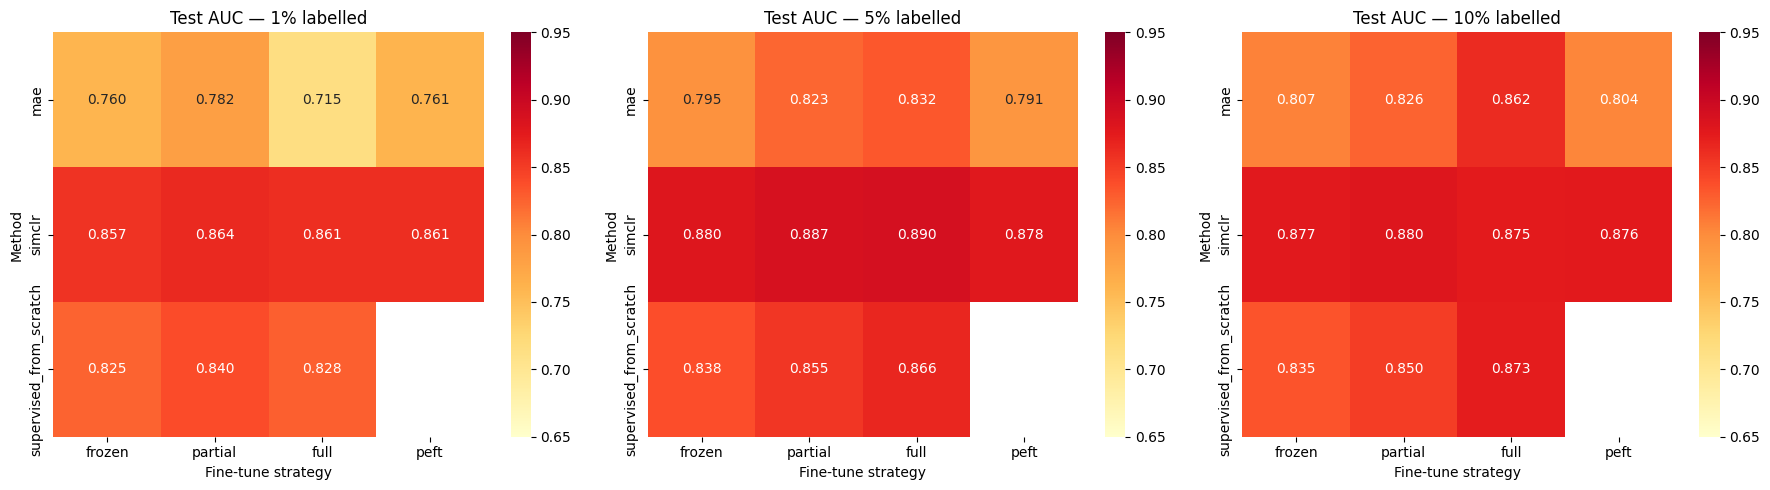

In [ ]:
# AUC heatmap: method × strategy, 1 panel per label fraction
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten summary's multi-index columns for simpler access
summary_flat = summary.copy()
summary_flat.columns = [
    '_'.join(filter(None, col)).strip('_') if isinstance(col, tuple) else col
    for col in summary_flat.columns.values
]
# Now columns are: method, strategy, label_fraction, test_auc_mean, test_auc_std, etc.

methods_arr = sorted(summary_flat['method'].unique())
strategies = ['frozen', 'partial', 'full', 'peft']
label_list = ['1%', '5%', '10%']

fig, axes = plt.subplots(1, len(label_list), figsize=(18, 5))
for ax, label in zip(axes, label_list):
    # Build methods × strategies matrix of mean AUC (NaN for skipped combos)
    matrix = np.full((len(methods_arr), len(strategies)), np.nan)
    for i, method in enumerate(methods_arr):
        for j, strat in enumerate(strategies):
            mask = (
                (summary_flat['method'] == method) &
                (summary_flat['strategy'] == strat) &
                (summary_flat['label_fraction'] == label)
            )
            row = summary_flat[mask]
            if len(row) > 0:
                matrix[i, j] = row['test_auc_mean'].values[0]

    sns.heatmap(
        matrix, annot=True, fmt='.3f',
        xticklabels=strategies, yticklabels=methods_arr,
        ax=ax, vmin=0.65, vmax=0.95, cmap='YlOrRd',
    )
    ax.set_title(f'Test AUC — {label} labelled')
    ax.set_xlabel('Fine-tune strategy')
    ax.set_ylabel('Method')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

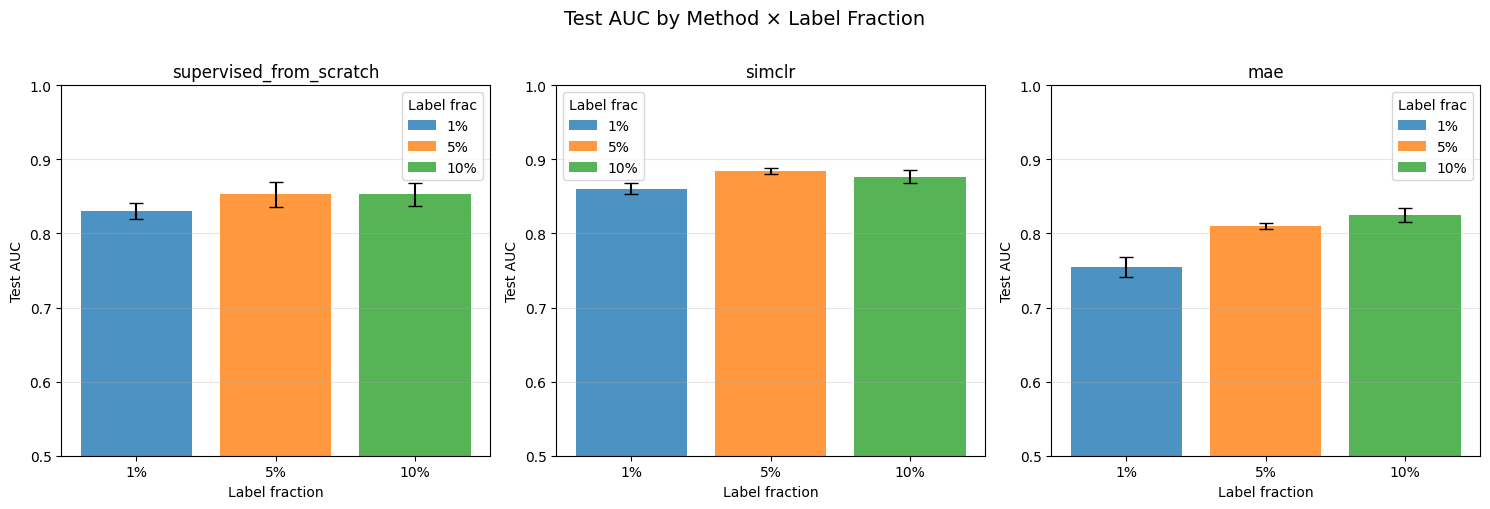

In [ ]:
# Plot val AUC progression across label fractions for each method
# We use the first seed's history from run_single_experiment
# If you re-ran with multiple seeds, extract history from the saved dicts.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))          

for ax, method in zip(axes, ['supervised_from_scratch', 'simclr', 'mae']):
    sub = results_df[results_df['method'] == method]
    for label in ['1%', '5%', '10%']:
        rows = sub[sub['label_fraction'] == label]
        means = rows.groupby('seed')['best_val_auc'].mean()
        aucs = rows.groupby('seed')['test_auc'].mean()
        ax.bar(label, aucs.mean(), yerr=aucs.std(), capsize=5,
               label=label, alpha=0.8)
    ax.set_title(method)
    ax.set_xlabel('Label fraction')
    ax.set_ylabel('Test AUC')
    ax.set_ylim(0.5, 1.0)
    ax.legend(title='Label frac')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Test AUC by Method × Label Fraction', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'auc_by_method_label.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Train best-config models ONCE, cache outputs for reuse
# by ROC, tSNE, Grad-CAM
from data import load_all_data, build_downstream_loaders, LABEL_FRACTIONS
from training import (
    build_simclr_classifier, build_supervised_scratch_classifier,
    build_mae_classifier, train_classifier,
    DEFAULT_EXPERIMENT_CONFIG, set_seed,
)
from evaluation import evaluate_model, extract_embeddings

# Configs to evaluate (10% labels, best strategy per method)
best_configs = [
    ('supervised_from_scratch', 'full',   None),
    ('simclr',                  'frozen', CHECKPOINT_DIR / 'simclr_encoder_tailored.pth'),
    ('mae',                     'frozen', CHECKPOINT_DIR / 'mae_encoder.pth'),
]

trained_models = {}  

for method, strategy, ckpt_path in best_configs:
    print(f"\n>>> Training {method} / {strategy} ...")
    set_seed(42)

    if method == 'supervised_from_scratch':
        model = build_supervised_scratch_classifier()
    elif method == 'simclr':
        model = build_simclr_classifier(ckpt_path)
    elif method == 'mae':
        model = build_mae_classifier(ckpt_path)

    model, _, _, _ = train_classifier(
        model, train_loaders['10%'], val_loader,
        strategy=strategy, config=DEFAULT_EXPERIMENT_CONFIG,
    )

    # Evaluate once (gives y_true, y_prob, y_pred)
    metrics = evaluate_model(model, test_loader)
    # Embeddings once
    embeddings, emb_labels = extract_embeddings(model, test_loader, method)

    trained_models[method] = {
        'model': model,
        'strategy': strategy,
        'metrics': metrics,
        'embeddings': embeddings,
        'emb_labels': emb_labels,
    }
    print(f"  checked {method}: test AUC = {metrics['auc']:.4f}")

print(f"\n Cached {len(trained_models)} models — downstream cells will reuse.")


>>> Training supervised_from_scratch / full ...
epoch 1/15 | train_loss=0.4814 | val_auc=0.8867 | val_f1=0.8116
epoch 2/15 | train_loss=0.3899 | val_auc=0.8129 | val_f1=0.6921
epoch 3/15 | train_loss=0.2779 | val_auc=0.8558 | val_f1=0.7836
epoch 4/15 | train_loss=0.1333 | val_auc=0.8604 | val_f1=0.7893
Early stopping triggered.
  ✓ supervised_from_scratch: test AUC = 0.8839

>>> Training simclr / frozen ...
epoch 1/15 | train_loss=0.4908 | val_auc=0.8653 | val_f1=0.6973
epoch 2/15 | train_loss=0.4239 | val_auc=0.8777 | val_f1=0.7742
epoch 3/15 | train_loss=0.4077 | val_auc=0.8817 | val_f1=0.7514
epoch 4/15 | train_loss=0.4111 | val_auc=0.8750 | val_f1=0.7276
epoch 5/15 | train_loss=0.4090 | val_auc=0.8832 | val_f1=0.7826
epoch 6/15 | train_loss=0.4057 | val_auc=0.8748 | val_f1=0.7281
epoch 7/15 | train_loss=0.3912 | val_auc=0.8816 | val_f1=0.7413
epoch 8/15 | train_loss=0.4009 | val_auc=0.8714 | val_f1=0.7190
Early stopping triggered.
  ✓ simclr: test AUC = 0.8746

>>> Training mae / 

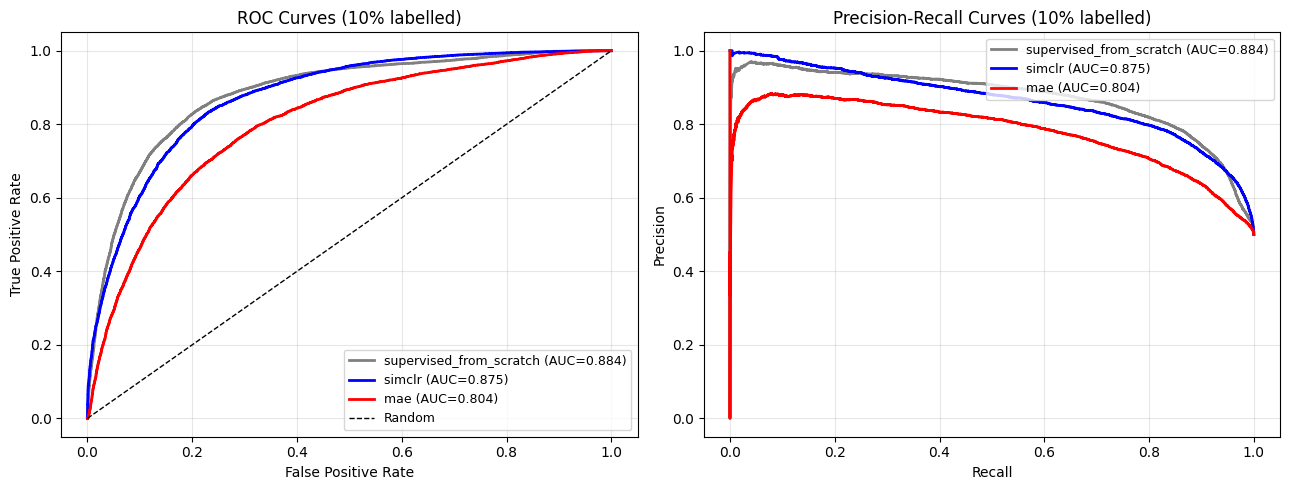

In [ ]:
# ROC + Precision-Recall curves 
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['gray', 'blue', 'red']

for (method, entry), color in zip(trained_models.items(), colors):
    m = entry['metrics']
    fpr, tpr, _ = roc_curve(m['y_true'], m['y_prob'])
    precision, recall, _ = precision_recall_curve(m['y_true'], m['y_prob'])

    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{method} (AUC={m['auc']:.3f})")
    axes[1].plot(recall, precision, color=color, lw=2,
                 label=f"{method} (AUC={m['auc']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (10% labelled)')
axes[0].legend(loc='lower right', fontsize=9); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (10% labelled)')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

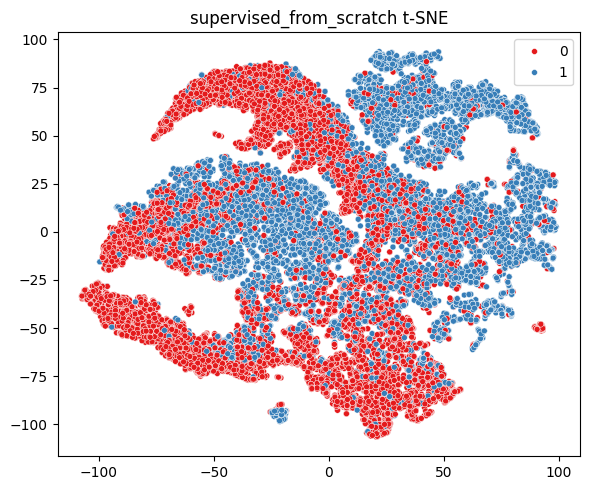

<Figure size 640x480 with 0 Axes>

t-SNE for supervised_from_scratch saved.


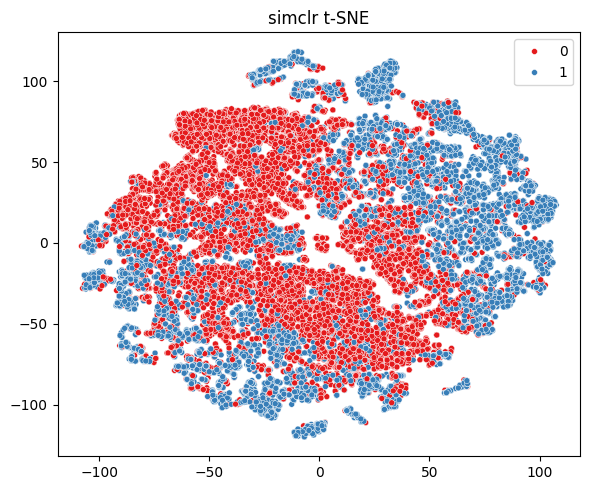

<Figure size 640x480 with 0 Axes>

t-SNE for simclr saved.


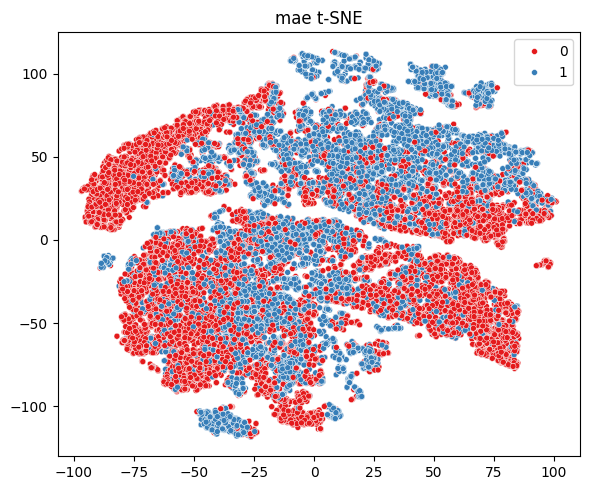

<Figure size 640x480 with 0 Axes>

t-SNE for mae saved.


In [ ]:
# t-SNE plots 
from evaluation import plot_tsne

for method, entry in trained_models.items():
    plot_tsne(entry['embeddings'], entry['emb_labels'], title=f'{method} t-SNE')
    plt.savefig(FIGURE_DIR / f'tsne_{method}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f't-SNE for {method} saved.')

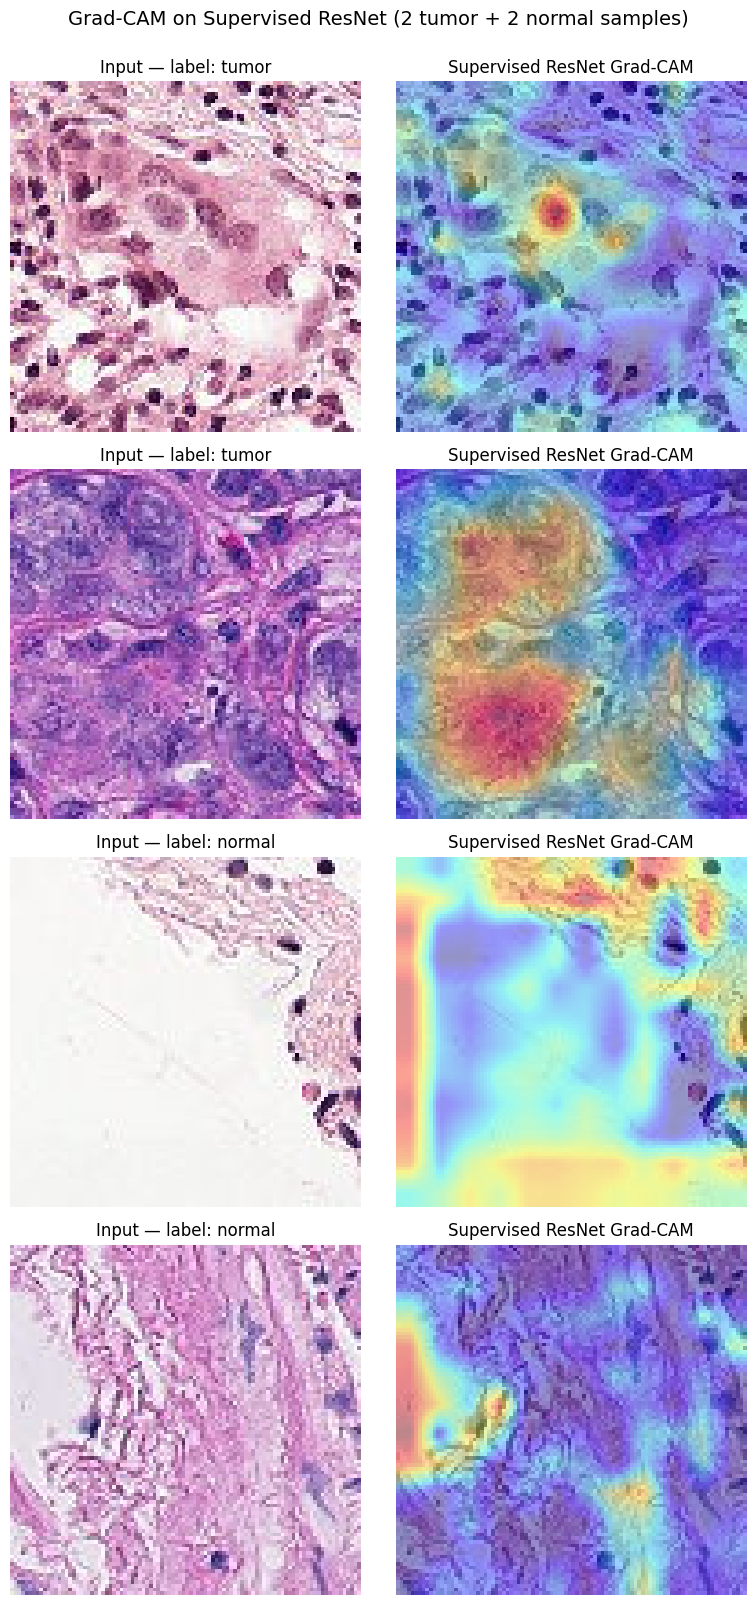

In [ ]:
import torch
from evaluation import GradCAM
from data import make_classification_transform

model_sup = trained_models['supervised_from_scratch']['model']
device = 'cuda' if torch.cuda.is_available() else 'cpu'
transform = make_classification_transform(data.channel_mean, data.channel_std)

# Pick 4 test images (2 positive + 2 negative)
pos_idx = [i for i in range(200) if int(data.y_test[i]) == 1][:2]
neg_idx = [i for i in range(200) if int(data.y_test[i]) == 0][:2]
indices = pos_idx + neg_idx

fig, axes = plt.subplots(len(indices), 2, figsize=(8, 4 * len(indices)))

for row, idx in enumerate(indices):
    img = data.x_test[idx]
    label = int(data.y_test[idx])
    img_tensor = transform(img).unsqueeze(0).to(device)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Input — label: {"tumor" if label == 1 else "normal"}')
    axes[row, 0].axis('off')

    cam_sup = GradCAM(model_sup.to(device), model_sup.encoder.layer4)
    heat_sup = cam_sup(img_tensor, class_idx=label)
    axes[row, 1].imshow(img)
    axes[row, 1].imshow(heat_sup, cmap='jet', alpha=0.4)
    axes[row, 1].set_title('Supervised ResNet Grad-CAM')
    axes[row, 1].axis('off')

plt.suptitle('Grad-CAM on Supervised ResNet (2 tumor + 2 normal samples)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'gradcam_supervised.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import os

print('Analysis Complete — Saved outputs')

print(f'\nResults:')
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f'  {RESULTS_DIR}/{f}')

print(f'\nFigures:')
for f in sorted(os.listdir(FIGURE_DIR)):
    size = os.path.getsize(FIGURE_DIR / f) / 1e3
    print(f'  {FIGURE_DIR}/{f}  ({size:.0f} KB)')

print('\nFinished.')

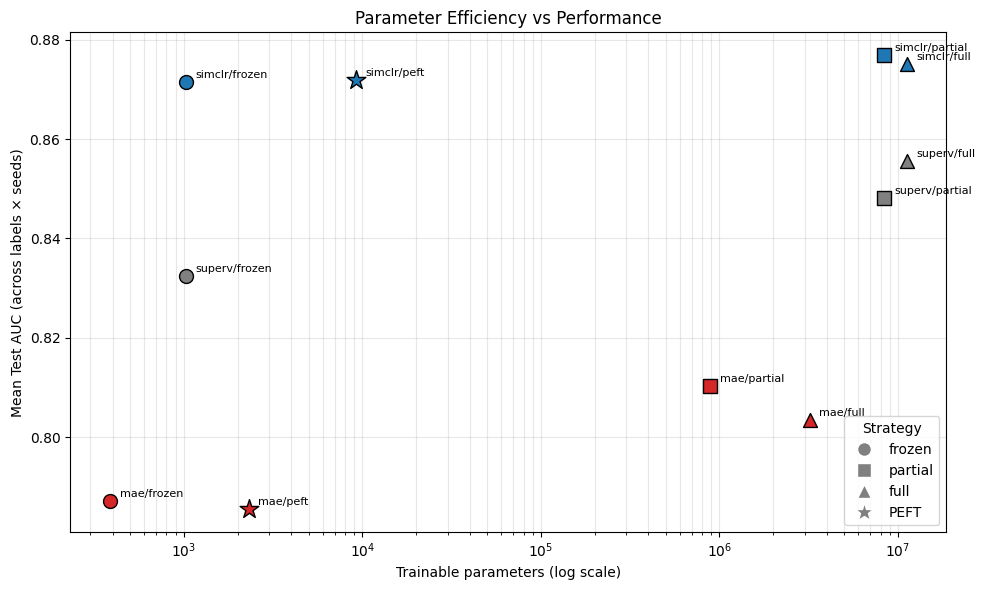


--- Trainable Params Summary ---
  mae                      frozen   →          386 params | AUC = 0.7872
  mae                      full     →    3,199,746 params | AUC = 0.8034
  mae                      partial  →      890,498 params | AUC = 0.8103
  mae                      peft     →        2,306 params | AUC = 0.7855
  simclr                   frozen   →        1,026 params | AUC = 0.8714
  simclr                   full     →   11,169,858 params | AUC = 0.8751
  simclr                   partial  →    8,394,754 params | AUC = 0.8769
  simclr                   peft     →        9,218 params | AUC = 0.8718
  supervised_from_scratch  frozen   →        1,026 params | AUC = 0.8325
  supervised_from_scratch  full     →   11,169,858 params | AUC = 0.8556
  supervised_from_scratch  partial  →    8,394,754 params | AUC = 0.8482


In [ ]:
# Pareto plot: trainable parameters vs test AUC
import matplotlib.pyplot as plt
from models import (
    count_trainable_params,
    build_simclr_classifier, build_mae_classifier, build_supervised_scratch_classifier,
    LoRAResNetClassifier, VPTMAEClassifier,
    configure_trainable_parameters,
)

# Count trainable params for each (method, strategy)
param_counts = {}

for method in ['supervised_from_scratch', 'simclr', 'mae']:
    for strategy in ['frozen', 'partial', 'full', 'peft']:
        if method == 'supervised_from_scratch' and strategy == 'peft':
            continue  

        # Build a fresh classifier for each config
        if method == 'supervised_from_scratch':
            model = build_supervised_scratch_classifier()
        elif method == 'simclr':
            model = build_simclr_classifier(CHECKPOINT_DIR / 'simclr_encoder_tailored.pth')
        elif method == 'mae':
            model = build_mae_classifier(CHECKPOINT_DIR / 'mae_encoder.pth')

        # Apply strategy
        if strategy == 'peft':
            if method == 'simclr':
                model = LoRAResNetClassifier(model.encoder, feature_dim=512, rank=8)
            elif method == 'mae':
                model = VPTMAEClassifier(model.encoder, num_prompts=10, embed_dim=192)
        else:
            configure_trainable_parameters(model, strategy)

        param_counts[(method, strategy)] = count_trainable_params(model)

# Average test AUC across labels × seeds for each (method, strategy)
mean_auc = results_df.groupby(['method', 'strategy'])['test_auc'].mean().to_dict()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

method_colors = {'supervised_from_scratch': 'gray', 'simclr': 'tab:blue', 'mae': 'tab:red'}
strategy_markers = {'frozen': 'o', 'partial': 's', 'full': '^', 'peft': '*'}

for (method, strategy), n_params in param_counts.items():
    auc = mean_auc.get((method, strategy), None)
    if auc is None:
        continue
    ax.scatter(
        n_params, auc,
        s=200 if strategy == 'peft' else 100,
        c=method_colors[method],
        marker=strategy_markers[strategy],
        edgecolors='black', linewidths=1,
        label=f"{method} / {strategy}",
        zorder=3 if strategy == 'peft' else 2,
    )
    ax.annotate(
        f"{method[:6]}/{strategy}",
        (n_params, auc),
        fontsize=8, xytext=(7, 3), textcoords='offset points',
    )

ax.set_xscale('log')
ax.set_xlabel('Trainable parameters (log scale)')
ax.set_ylabel('Mean Test AUC (across labels × seeds)')
ax.set_title('Parameter Efficiency vs Performance')
ax.grid(True, which='both', alpha=0.3)

# Legend by marker (strategy) only
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='frozen'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='partial'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, label='full'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markersize=14, label='PEFT'),
]
ax.legend(handles=legend_elems, title='Strategy', loc='lower right')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'pareto_params_vs_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# A summary table
print("\n Trainable Params Summary ")
for (method, strategy), n_params in sorted(param_counts.items()):
    auc = mean_auc.get((method, strategy), float('nan'))
    print(f"  {method:<24} {strategy:<8} -> {n_params:>12,} params | AUC = {auc:.4f}")